<a href="https://colab.research.google.com/github/emilsar/Cedars/blob/main/Project3/Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Load Libraries

In [6]:

from skimage.io import imread
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from skimage.color import rgb2gray
from skimage.filters import sobel, scharr, apply_hysteresis_threshold, gaussian
from skimage.feature import canny
from skimage.measure import regionprops,regionprops_table
from skimage.morphology import binary_opening, disk, binary_closing, binary_dilation, binary_erosion
from skimage.draw import rectangle_perimeter
from scipy.ndimage import label as scilabel
import cv2
import matplotlib; matplotlib.rcParams['figure.dpi']=300
from scipy.ndimage import gaussian_filter
from skimage.restoration import denoise_nl_means
from skimage.filters import unsharp_mask

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split

# Load Cedars Data

In [7]:
!git clone https://github.com/emilsar/Cedars.git
%cd Cedars/Project3
! python 1_prepdata.py
urothelial_cells=pd.read_pickle("urothelial_cell_toy_data.pkl")
images=np.transpose(urothelial_cells["X"].numpy()*255,(0,2,3,1)).astype(np.uint8)
labels=urothelial_cells["y"]

Cloning into 'Cedars'...
remote: Enumerating objects: 1308, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 1308 (delta 30), reused 4 (delta 4), pack-reused 1257 (from 3)
Receiving objects: 100% (1308/1308), 1.23 GiB | 24.82 MiB/s, done.
Resolving deltas: 100% (510/510), done.
Updating files: 100% (899/899), done.
/content/Cedars/Project3/Cedars/Project3


#Automated Pipeline

##Metric Functions

In [8]:
import numpy as np

def dice_coefficient(pred, target, class_label):
    """
    Calculate Dice coefficient for a specific class.

    Parameters:
    -----------
    pred : np.ndarray
        Predicted segmentation (integer labels)
    target : np.ndarray
        Ground truth segmentation (integer labels)
    class_label : int
        The class to evaluate (0, 1, or 2)

    Returns:
    --------
    dice : float
        Dice coefficient for this class (0 to 1)
    """
    pred_binary = (pred == class_label).astype(float)
    target_binary = (target == class_label).astype(float)

    intersection = np.sum(pred_binary * target_binary)
    sum_pred = np.sum(pred_binary)
    sum_target = np.sum(target_binary)

    # Handle edge case where both pred and target are empty
    if sum_pred == 0 and sum_target == 0:
        return 1.0

    if sum_pred + sum_target == 0:
        return 0.0

    dice = 2 * intersection / (sum_pred + sum_target)
    return dice

def iou_coefficient(pred, target, class_label):
    """
    Calculate Intersection over Union (IoU) for a specific class.

    Parameters:
    -----------
    pred : np.ndarray
        Predicted segmentation (integer labels)
    target : np.ndarray
        Ground truth segmentation (integer labels)
    class_label : int
        The class to evaluate (0, 1, or 2)

    Returns:
    --------
    iou : float
        IoU for this class (0 to 1)
    """
    pred_binary = (pred == class_label).astype(float)
    target_binary = (target == class_label).astype(float)

    intersection = np.sum(pred_binary * target_binary)
    union = np.sum(np.logical_or(pred_binary, target_binary))

    # Handle edge case where union is empty
    if union == 0:
        return 1.0 if intersection == 0 else 0.0

    iou = intersection / union
    return iou

def calculate_all_metrics(pred, target, class_labels=[0, 1, 2]):
    """
    Calculate Dice and IoU for all classes plus mean metrics.

    Returns:
    --------
    metrics : dict
        Dictionary containing per-class and mean metrics
    """
    metrics = {}

    dice_scores = []
    iou_scores = []

    for class_label in class_labels:
        dice = dice_coefficient(pred, target, class_label)
        iou = iou_coefficient(pred, target, class_label)

        class_name = ['Background', 'Cytoplasm', 'Nucleus'][class_label]
        metrics[f'Dice_{class_name}'] = dice
        metrics[f'IoU_{class_name}'] = iou

        dice_scores.append(dice)
        iou_scores.append(iou)

    metrics['Dice_Mean'] = np.mean(dice_scores)
    metrics['IoU_Mean'] = np.mean(iou_scores)

    return metrics

def print_metrics(metrics):
    """Pretty-print metrics table."""
    print("=" * 70)
    print(f"{'Class':<15} {'Dice':<15} {'IoU':<15}")
    print("=" * 70)

    class_names = ['Background', 'Cytoplasm', 'Nucleus']
    for i, class_name in enumerate(class_names):
        dice = metrics[f'Dice_{class_name}']
        iou = metrics[f'IoU_{class_name}']
        print(f"{class_name:<15} {dice:<15.4f} {iou:<15.4f}")

    print("-" * 70)
    print(f"{'Mean':<15} {metrics['Dice_Mean']:<15.4f} {metrics['IoU_Mean']:<15.4f}")
    print("=" * 70)

def compute_aggregate_metrics(all_metrics):
    """
    Compute mean and standard deviation of metrics across all images.

    Parameters:
    -----------
    all_metrics : list of dict
        Metrics for each image

    Returns:
    --------
    aggregate : dict
        Mean and std for each metric
    """

    aggregate = {}

    # Get all metric keys from first image
    if not all_metrics:
        return aggregate

    metric_keys = all_metrics[0].keys()

    for key in metric_keys:
        values = [m[key] for m in all_metrics]
        aggregate[f'{key}_mean'] = np.mean(values)
        aggregate[f'{key}_std'] = np.std(values)

    return aggregate

def print_aggregate_metrics(aggregate_metrics):
    """Pretty-print aggregate metrics."""
    print("\n" + "="*85)
    print(f"{'Metric':<25} {'Mean':<20} {'Std Dev':<20}")
    print("="*85)

    class_names = ['Background', 'Cytoplasm', 'Nucleus']

    # Print per-class Dice
    for class_name in class_names:
        key = f'Dice_{class_name}'
        mean = aggregate_metrics.get(f'{key}_mean', 0)
        std = aggregate_metrics.get(f'{key}_std', 0)
        print(f"{key:<25} {mean:<20.4f} {std:<20.4f}")

    print("-"*85)

    # Print Mean Dice
    key = 'Dice_Mean'
    mean = aggregate_metrics.get(f'{key}_mean', 0)
    std = aggregate_metrics.get(f'{key}_std', 0)
    print(f"{key:<25} {mean:<20.4f} {std:<20.4f}")

    print("-"*85)

    # Print per-class IoU
    for class_name in class_names:
        key = f'IoU_{class_name}'
        mean = aggregate_metrics.get(f'{key}_mean', 0)
        std = aggregate_metrics.get(f'{key}_std', 0)
        print(f"{key:<25} {mean:<20.4f} {std:<20.4f}")

    print("-"*85)

    # Print Mean IoU
    key = 'IoU_Mean'
    mean = aggregate_metrics.get(f'{key}_mean', 0)
    std = aggregate_metrics.get(f'{key}_std', 0)
    print(f"{key:<25} {mean:<20.4f} {std:<20.4f}")

    print("="*85)

def visualize_metric_distributions(all_metrics):
    """
    Create histograms showing distribution of metrics across dataset.

    Parameters:
    -----------
    all_metrics : list of dict
        Metrics for each image
    """

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle('Distribution of Segmentation Metrics Across Dataset',
                 fontsize=14, fontweight='bold')

    # Extract metric values
    dice_bg = [m['Dice_Background'] for m in all_metrics]
    dice_cyto = [m['Dice_Cytoplasm'] for m in all_metrics]
    dice_nuc = [m['Dice_Nucleus'] for m in all_metrics]

    iou_bg = [m['IoU_Background'] for m in all_metrics]
    iou_cyto = [m['IoU_Cytoplasm'] for m in all_metrics]
    iou_nuc = [m['IoU_Nucleus'] for m in all_metrics]

    # Dice histograms
    axes[0, 0].hist(dice_bg, bins=30, alpha=0.7, color='blue', edgecolor='black')
    axes[0, 0].set_title('Dice - Background', fontweight='bold')
    axes[0, 0].set_xlabel('Dice Score')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].grid(alpha=0.3)
    axes[0, 0].axvline(np.mean(dice_bg), color='red', linestyle='--', linewidth=2,
                       label=f'Mean: {np.mean(dice_bg):.3f}')
    axes[0, 0].legend()

    axes[0, 1].hist(dice_cyto, bins=30, alpha=0.7, color='orange', edgecolor='black')
    axes[0, 1].set_title('Dice - Cytoplasm', fontweight='bold')
    axes[0, 1].set_xlabel('Dice Score')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].grid(alpha=0.3)
    axes[0, 1].axvline(np.mean(dice_cyto), color='red', linestyle='--', linewidth=2,
                       label=f'Mean: {np.mean(dice_cyto):.3f}')
    axes[0, 1].legend()

    axes[0, 2].hist(dice_nuc, bins=30, alpha=0.7, color='green', edgecolor='black')
    axes[0, 2].set_title('Dice - Nucleus', fontweight='bold')
    axes[0, 2].set_xlabel('Dice Score')
    axes[0, 2].set_ylabel('Frequency')
    axes[0, 2].grid(alpha=0.3)
    axes[0, 2].axvline(np.mean(dice_nuc), color='red', linestyle='--', linewidth=2,
                       label=f'Mean: {np.mean(dice_nuc):.3f}')
    axes[0, 2].legend()

    # IoU histograms
    axes[1, 0].hist(iou_bg, bins=30, alpha=0.7, color='blue', edgecolor='black')
    axes[1, 0].set_title('IoU - Background', fontweight='bold')
    axes[1, 0].set_xlabel('IoU Score')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].grid(alpha=0.3)
    axes[1, 0].axvline(np.mean(iou_bg), color='red', linestyle='--', linewidth=2,
                       label=f'Mean: {np.mean(iou_bg):.3f}')
    axes[1, 0].legend()

    axes[1, 1].hist(iou_cyto, bins=30, alpha=0.7, color='orange', edgecolor='black')
    axes[1, 1].set_title('IoU - Cytoplasm', fontweight='bold')
    axes[1, 1].set_xlabel('IoU Score')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].grid(alpha=0.3)
    axes[1, 1].axvline(np.mean(iou_cyto), color='red', linestyle='--', linewidth=2,
                       label=f'Mean: {np.mean(iou_cyto):.3f}')
    axes[1, 1].legend()

    axes[1, 2].hist(iou_nuc, bins=30, alpha=0.7, color='green', edgecolor='black')
    axes[1, 2].set_title('IoU - Nucleus', fontweight='bold')
    axes[1, 2].set_xlabel('IoU Score')
    axes[1, 2].set_ylabel('Frequency')
    axes[1, 2].grid(alpha=0.3)
    axes[1, 2].axvline(np.mean(iou_nuc), color='red', linestyle='--', linewidth=2,
                       label=f'Mean: {np.mean(iou_nuc):.3f}')
    axes[1, 2].legend()

    plt.tight_layout()
    plt.show()

def calculate_nc_ratio(label_image):
    """
    Calculate the nucleus-to-cytoplasm area ratio.

    Parameters:
    -----------
    label_image : np.ndarray
        Segmented label image (0=background, 1=cytoplasm, 2=nucleus)

    Returns:
    --------
    nc_ratio : float
        Ratio of nucleus area to cytoplasm area
        Returns 0 if cytoplasm area is 0 (to avoid division by zero)
    """
    nucleus_area = np.sum(label_image == 2)
    cytoplasm_area = np.sum(label_image == 1)

    if cytoplasm_area == 0:
        return 0.0

    nc_ratio = nucleus_area / cytoplasm_area
    return nc_ratio

def compute_nc_ratios(labels_list):
    """
    Compute nucleus-to-cytoplasm ratios for all images.

    Parameters:
    -----------
    labels_list : list of np.ndarray
        List of label images

    Returns:
    --------
    nc_ratios : np.ndarray
        Array of NC ratios, one per image
    """
    nc_ratios = np.array([calculate_nc_ratio(label_img) for label_img in labels_list])
    return nc_ratios

def analyze_nc_ratios(labels_true, labels_pred):
    """
    Compute and visualize N/C ratio metrics.

    Parameters:
    -----------
    labels_true : list of np.ndarray
        Ground truth label images
    labels_pred : list of np.ndarray
        Predicted segmentation images
    dataset_name : str
        Name for output printing
    """

    # Compute N/C ratios
    nc_ratio_true = compute_nc_ratios(labels_true)
    nc_ratio_pred = compute_nc_ratios(labels_pred)

    # Calculate errors
    absolute_errors = np.abs(nc_ratio_pred - nc_ratio_true)
    relative_errors = np.abs(nc_ratio_pred - nc_ratio_true) / (nc_ratio_true + 1e-6)

    # Print statistics
    print(f"N/C Ratio Statistics:")
    print(f"  True N/C Ratio - Mean: {np.mean(nc_ratio_true):.4f}, Std: {np.std(nc_ratio_true):.4f}")
    print(f"  Pred N/C Ratio - Mean: {np.mean(nc_ratio_pred):.4f}, Std: {np.std(nc_ratio_pred):.4f}")
    print(f"  Absolute Error - Mean: {np.mean(absolute_errors):.4f}, Std: {np.std(absolute_errors):.4f}")
    print(f"  Relative Error - Mean: {np.mean(relative_errors):.4f}, Std: {np.std(relative_errors):.4f}")

    # Create scatter plot
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.scatter(nc_ratio_pred, nc_ratio_true, alpha=0.6, s=8)
    ax.plot([0, 5], [0, 5], ls="--", color='red', linewidth=2, label='Perfect Prediction')
    ax.set_xlabel("Predicted N/C Ratio", fontsize=5, fontweight='bold')
    ax.set_ylabel("True N/C Ratio", fontsize=5, fontweight='bold')
    ax.set_title(f"N/C Ratio: Predicted vs. True ({dataset_name})", fontsize=5, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)
    max_val = max(nc_ratio_pred.max(), nc_ratio_true.max()) * 1.1
    ax.set_xlim([0, max_val])
    ax.set_ylim([0, max_val])
    plt.tight_layout()
    plt.show()



##Data Cleaning Functions

In [9]:
import numpy as np
from skimage.measure import label

def count_nuclei(label_image, nucleus_value=2):
    """
    Count the number of distinct nuclei (connected components) in a labeled image.

    Parameters:
    -----------
    label_image : np.ndarray
        2D array where each pixel is labeled with integer values
        (0=background, 1=cytoplasm, 2=nucleus)
    nucleus_value : int
        The intensity value representing nucleus pixels (default: 2)

    Returns:
    --------
    num_nuclei : int
        The number of connected components with nucleus label
    component_map : np.ndarray
        2D array where each nucleus component is assigned a unique ID
        (starting from 1; background is 0)
    """

    # Extract only the nucleus pixels (create binary mask)
    nucleus_mask = (label_image == nucleus_value).astype(int)

    # Apply connected component labeling
    # return_num=True gives us both the labeled map and the count
    component_map, num_nuclei = label(nucleus_mask, connectivity=2, return_num=True)

    return num_nuclei, component_map

def analyze_nucleus_distribution(labels_list):
    """
    Analyze the distribution of nucleus counts across the entire dataset.

    Parameters:
    -----------
    labels_list : list of np.ndarray
        List of all ground truth label images in the dataset

    Returns:
    --------
    nucleus_counts : np.ndarray
        Array where index i contains the count of images with i nuclei
    image_nucleus_info : list of tuples
        List of (image_index, num_nuclei) for each image
    """

    image_nucleus_info = []
    max_nuclei = 0

    for idx, label_image in enumerate(labels_list):
        num_nuclei, _ = count_nuclei(label_image, nucleus_value=2)
        image_nucleus_info.append((idx, num_nuclei))
        max_nuclei = max(max_nuclei, num_nuclei)

    # Create histogram
    nucleus_counts = np.zeros(max_nuclei + 1, dtype=int)
    for idx, num_nuclei in image_nucleus_info:
        nucleus_counts[num_nuclei] += 1

    return nucleus_counts, image_nucleus_info

def filter_images_by_nucleus_count(images, labels, min_nuclei=1, max_nuclei=1):
    """
    Filter images to keep only those with an acceptable number of nuclei.

    Parameters:
    -----------
    images : list of np.ndarray
        List of raw cell images
    labels : list of np.ndarray
        List of corresponding label images
    min_nuclei : int
        Minimum acceptable number of nuclei (default: 1)
    max_nuclei : int
        Maximum acceptable number of nuclei (default: 1)

    Returns:
    --------
    filtered_images : list of np.ndarray
        Filtered image list
    filtered_labels : list of np.ndarray
        Filtered label list
    valid_indices : list of int
        Indices of images that passed the filter in original dataset
    filtering_report : dict
        Detailed statistics about the filtering
    """

    valid_indices = []
    excluded_indices = []
    excluded_reasons = {
        'no_nucleus': [],
        'too_few_nuclei': [],
        'too_many_nuclei': []
    }

    for idx, label_img in enumerate(labels):
        num_nuclei, _ = count_nuclei(label_img, nucleus_value=2)

        if num_nuclei == 0:
            excluded_indices.append(idx)
            excluded_reasons['no_nucleus'].append(idx)
        elif num_nuclei < min_nuclei:
            excluded_indices.append(idx)
            excluded_reasons['too_few_nuclei'].append(idx)
        elif num_nuclei > max_nuclei:
            excluded_indices.append(idx)
            excluded_reasons['too_many_nuclei'].append(idx)
        else:
            valid_indices.append(idx)

    filtered_images = [images[i] for i in valid_indices]
    filtered_labels = [labels[i] for i in valid_indices]

    filtering_report = {
        'original_count': len(images),
        'filtered_count': len(filtered_images),
        'excluded_count': len(excluded_indices),
        'no_nucleus': len(excluded_reasons['no_nucleus']),
        'too_few_nuclei': len(excluded_reasons['too_few_nuclei']),
        'too_many_nuclei': len(excluded_reasons['too_many_nuclei']),
        'exclusion_rate': len(excluded_indices) / len(images) * 100
    }

    return filtered_images, filtered_labels, valid_indices, filtering_report

def visualize_nucleus_distribution(nucleus_counts, labels_list=None):
    """
    Visualize the distribution of nucleus counts in the dataset.

    Parameters:
    -----------
    nucleus_counts : np.ndarray
        Array where index i contains count of images with i nuclei
    labels_list : list of np.ndarray, optional
        If provided, compute distribution from scratch
    """

    if labels_list is not None:
        nucleus_counts, _ = analyze_nucleus_distribution(labels_list)

    fig, ax = plt.subplots(figsize=(5,3))

    nuclei_indices = np.arange(len(nucleus_counts))
    colors = ['red' if i != 1 else 'green' for i in nuclei_indices]

    bars = ax.bar(nuclei_indices, nucleus_counts, color=colors, alpha=0.7, edgecolor='black')

    ax.set_xlabel('Number of Nuclei per Image', fontsize=5, fontweight='bold')
    ax.set_ylabel('Count of Images', fontsize=5, fontweight='bold')
    ax.set_title('Distribution of Nucleus Counts in Dataset', fontsize=5, fontweight='bold')
    ax.set_xticks(nuclei_indices)
    ax.grid(axis='y', alpha=0.3)

    # Add count labels on bars
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}',
                   ha='center', va='bottom', fontweight='bold')

    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='green', alpha=0.7, edgecolor='black', label='Keep (1 nucleus)'),
        Patch(facecolor='red', alpha=0.7, edgecolor='black', label='Exclude (not 1 nucleus)')
    ]
    ax.legend(handles=legend_elements, fontsize=11, loc='upper right')

    plt.tight_layout()
    plt.show()

    # Print statistics
    print("\n" + "="*70)
    print("NUCLEUS DISTRIBUTION STATISTICS")
    print("="*70)
    print(f"{'# Nuclei':<15} {'Count':<15} {'Percentage':<15}")
    print("-"*70)
    total = np.sum(nucleus_counts)
    for i, count in enumerate(nucleus_counts):
        percentage = count / total * 100 if total > 0 else 0
        status = "[KEEP]" if i == 1 else "[EXCLUDE]"
        print(f"{i:<15} {count:<15} {percentage:<15.2f}%  {status}")
    print("="*70)

##Major Pipeline Functions

In [10]:
def apply_stage4_pipeline(img, labels_true, params):
    """
    Apply the complete 4-stage preprocessing pipeline to a single image.

    Parameters:
    -----------
    img : np.ndarray
        RGB image (H, W, 3)
    labels_true : np.ndarray
        Ground truth segmentation labels
    params : dict
        Pipeline parameters:
        - nucleus_max, cytoplasm_min, cytoplasm_max: thresholds
        - nl_means_strength: denoising parameter h
        - unsharp_radius, unsharp_amount: edge enhancement
        - blur_sigma: Gaussian blur standard deviation
        - morph_disk_size: morphological opening kernel
        - closing_disk_size: morphological closing kernel

    Returns:
    --------
    segmented : np.ndarray
        Final predicted segmentation
    metrics : dict
        Calculated metrics (Dice, IoU for each class)
    """

    # STAGE 1: Grayscale Conversion
    img_uint8 = img.astype(np.uint8)
    img_gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0

    # STAGE 2: Non-Local Means Denoising
    img_denoised = denoise_nl_means(
        img_gray,
        h=params['nl_means_strength'],
        fast_mode=True,
        patch_size=10,
        patch_distance=10
    )

    # STAGE 3: Edge Enhancement and Blur
    img_enhanced = unsharp_mask(
        img_denoised,
        radius=params['unsharp_radius'],
        amount=params['unsharp_amount']
    )
    img_blurred = gaussian_filter(img_enhanced, sigma=params['blur_sigma'])

    # Intensity-Based Segmentation
    nucleus_mask = (img_blurred < params['nucleus_max']).astype(int)
    cytoplasm_mask = np.logical_and(
        img_blurred >= params['cytoplasm_min'],
        img_blurred <= params['cytoplasm_max']
    ).astype(int)

    # STAGE 4: Morphological Operations
    nucleus_opened = binary_opening(nucleus_mask, disk(params['morph_disk_size'])).astype(int)
    cytoplasm_opened = binary_opening(cytoplasm_mask, disk(params['morph_disk_size'])).astype(int)

    nucleus_closed = binary_closing(nucleus_opened, disk(params['closing_disk_size'])).astype(int)
    cytoplasm_closed = binary_closing(cytoplasm_opened, disk(params['closing_disk_size'])).astype(int)

    # Combine into 3-class segmentation
    segmented = np.zeros_like(img_blurred, dtype=int)
    segmented[nucleus_closed == 1] = 2
    segmented[cytoplasm_closed == 1] = 1

    # Calculate metrics
    metrics = calculate_all_metrics(segmented, labels_true, class_labels=[0, 1, 2])

    return segmented, metrics

def apply_pipeline_to_dataset(images, labels, params, verbose=True):
    """
    Apply the preprocessing pipeline to all images in the dataset.

    Parameters:
    -----------
    images : list of np.ndarray
        List of RGB images
    labels : list of np.ndarray
        List of ground truth segmentations
    params : dict
        Pipeline parameters
    verbose : bool
        Print progress updates

    Returns:
    --------
    segmented_images : list of np.ndarray
        Preprocessed segmentations for all images
    all_metrics : list of dict
        Metrics for each image
    aggregate_metrics : dict
        Mean and std of metrics across dataset
    """

    segmented_images = []
    all_metrics = []

    total_images = len(images)

    for idx, (img, label_true) in enumerate(zip(images, labels)):
        if verbose and (idx + 1) % 10 == 0:
            print(f"Processing image {idx + 1}/{total_images}...")

        segmented, metrics = apply_stage4_pipeline(img, label_true, params)
        segmented_images.append(segmented)
        all_metrics.append(metrics)

    # Compute aggregate metrics
    aggregate_metrics = compute_aggregate_metrics(all_metrics)

    if verbose:
        print(f"Completed processing all {total_images} images.")

    return segmented_images, all_metrics, aggregate_metrics





##Implementation of Data Cleaning

Analyzing nucleus distribution...

Filtering dataset...

FILTERING REPORT
Original dataset size: 200 images
After filtering: 108 images
Excluded: 92 images (46.00%)
  - No nucleus: 9 images
  - Too few nuclei: 0 images
  - Too many nuclei: 83 images


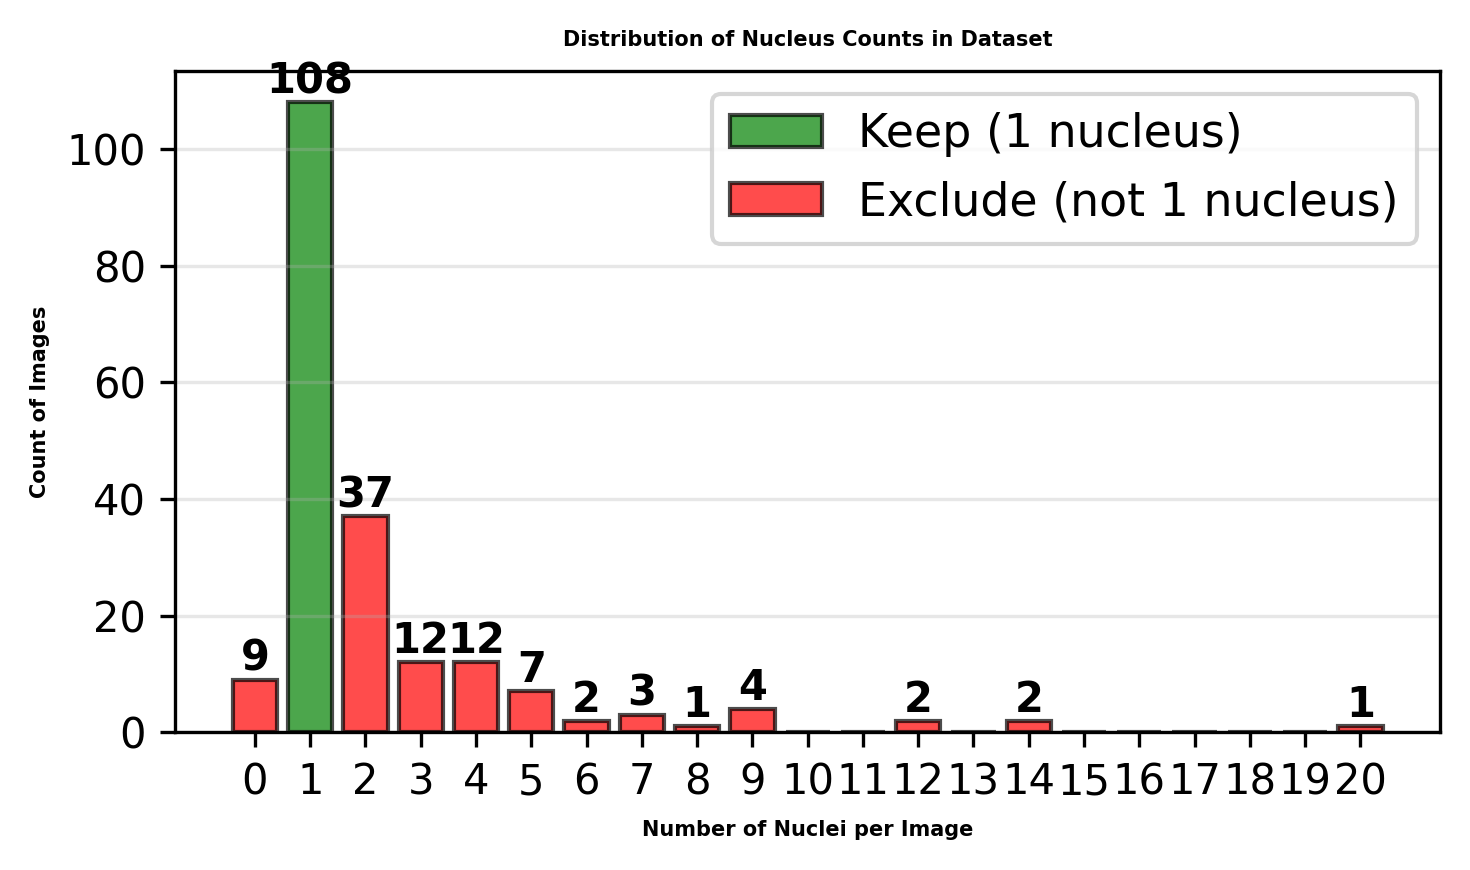


NUCLEUS DISTRIBUTION STATISTICS
# Nuclei        Count           Percentage     
----------------------------------------------------------------------
0               9               4.50           %  [EXCLUDE]
1               108             54.00          %  [KEEP]
2               37              18.50          %  [EXCLUDE]
3               12              6.00           %  [EXCLUDE]
4               12              6.00           %  [EXCLUDE]
5               7               3.50           %  [EXCLUDE]
6               2               1.00           %  [EXCLUDE]
7               3               1.50           %  [EXCLUDE]
8               1               0.50           %  [EXCLUDE]
9               4               2.00           %  [EXCLUDE]
10              0               0.00           %  [EXCLUDE]
11              0               0.00           %  [EXCLUDE]
12              2               1.00           %  [EXCLUDE]
13              0               0.00           %  [EXCLUDE]
14         

In [11]:
# Assume images and labels are already loaded
#Filtering Process
print("Analyzing nucleus distribution...")
nucleus_counts, image_nucleus_info = analyze_nucleus_distribution(labels)

print("\nFiltering dataset...")
filtered_images, filtered_labels, valid_indices, report = filter_images_by_nucleus_count(
    images,
    labels,
    min_nuclei=1,
    max_nuclei=1
)

print("\n" + "="*70)
print("FILTERING REPORT")
print("="*70)
print(f"Original dataset size: {report['original_count']} images")
print(f"After filtering: {report['filtered_count']} images")
print(f"Excluded: {report['excluded_count']} images ({report['exclusion_rate']:.2f}%)")
print(f"  - No nucleus: {report['no_nucleus']} images")
print(f"  - Too few nuclei: {report['too_few_nuclei']} images")
print(f"  - Too many nuclei: {report['too_many_nuclei']} images")
print("="*70)

# Visualize filtered images distribution
visualize_nucleus_distribution(nucleus_counts)


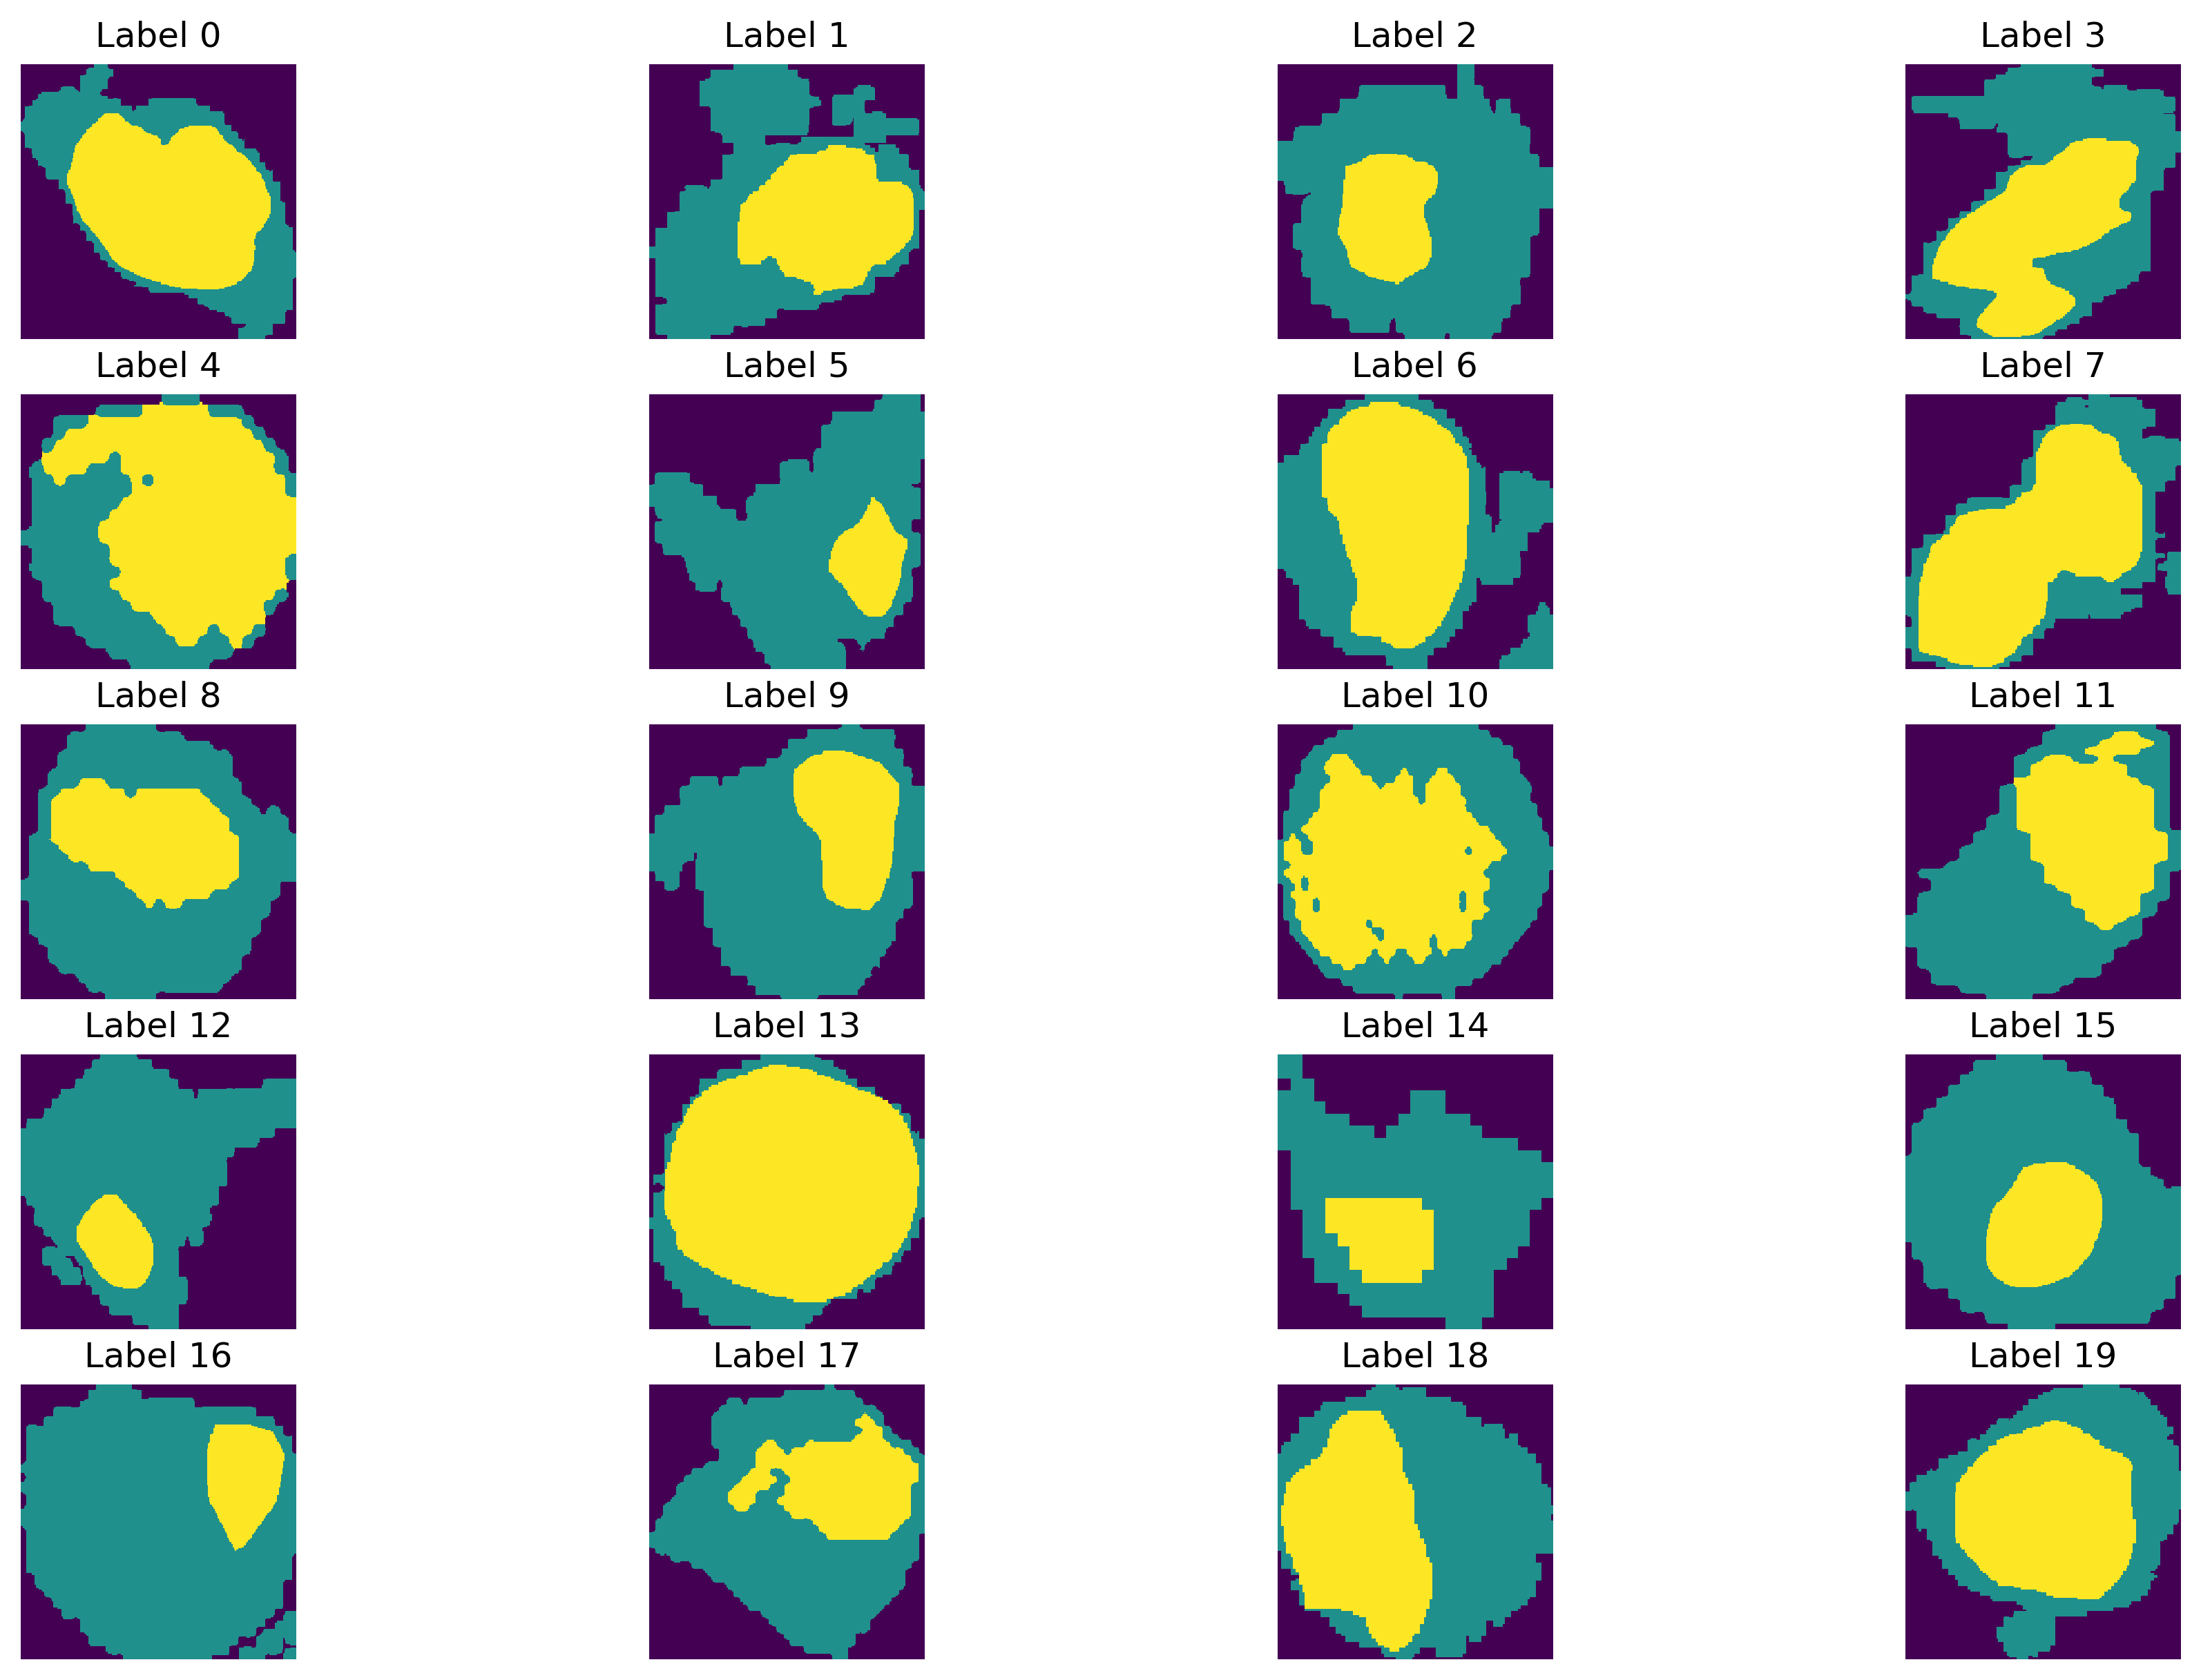

In [12]:
fig, axes = plt.subplots(5, 4, figsize=(15, 10))
k=0
for i in range(5):
  for j in range(4):
      axes[i, j].imshow(filtered_labels[k], cmap='viridis', interpolation='nearest')
      axes[i, j].set_title(f"Label {k}")
      axes[i, j].axis('off')
      k=k+1



## WorkFlow 1.0

In [13]:
print("\nFiltering dataset...")
filtered_images, filtered_labels, valid_indices, report = filter_images_by_nucleus_count(
    images,
    labels,
    min_nuclei=1,
    max_nuclei=1
)

# Example workflow
print("Applying pipeline to entire dataset...")

# Define parameters (determined from tuning on sample images in Chapter 4)
pipeline_params = {
    'nucleus_max': 0.449,
    'cytoplasm_min': 0.449,
    'cytoplasm_max': 0.977,
    'nl_means_strength': 0.3,
    'unsharp_radius': 2.0,
    'unsharp_amount': 1.0,
    'blur_sigma': 1.5,
    'morph_disk_size': 3,
    'closing_disk_size': 2
}

#Apply Pipeline.  Returns segmented_images, all_metrics, aggregate_metrics
segmented_images, all_metrics, aggregate_metrics = apply_pipeline_to_dataset(
    filtered_images,
    filtered_labels,
    pipeline_params,
    verbose=True
)




Filtering dataset...
Applying pipeline to entire dataset...
Processing image 10/108...
Processing image 20/108...
Processing image 30/108...
Processing image 40/108...
Processing image 50/108...
Processing image 60/108...
Processing image 70/108...
Processing image 80/108...
Processing image 90/108...
Processing image 100/108...
Completed processing all 108 images.


### Display of Metrics


Metric                    Mean                 Std Dev             
Dice_Background           0.9144               0.0369              
Dice_Cytoplasm            0.7785               0.1198              
Dice_Nucleus              0.7374               0.2192              
-------------------------------------------------------------------------------------
Dice_Mean                 0.8101               0.0956              
-------------------------------------------------------------------------------------
IoU_Background            0.8444               0.0597              
IoU_Cytoplasm             0.6523               0.1534              
IoU_Nucleus               0.6249               0.2399              
-------------------------------------------------------------------------------------
IoU_Mean                  0.7072               0.1099              


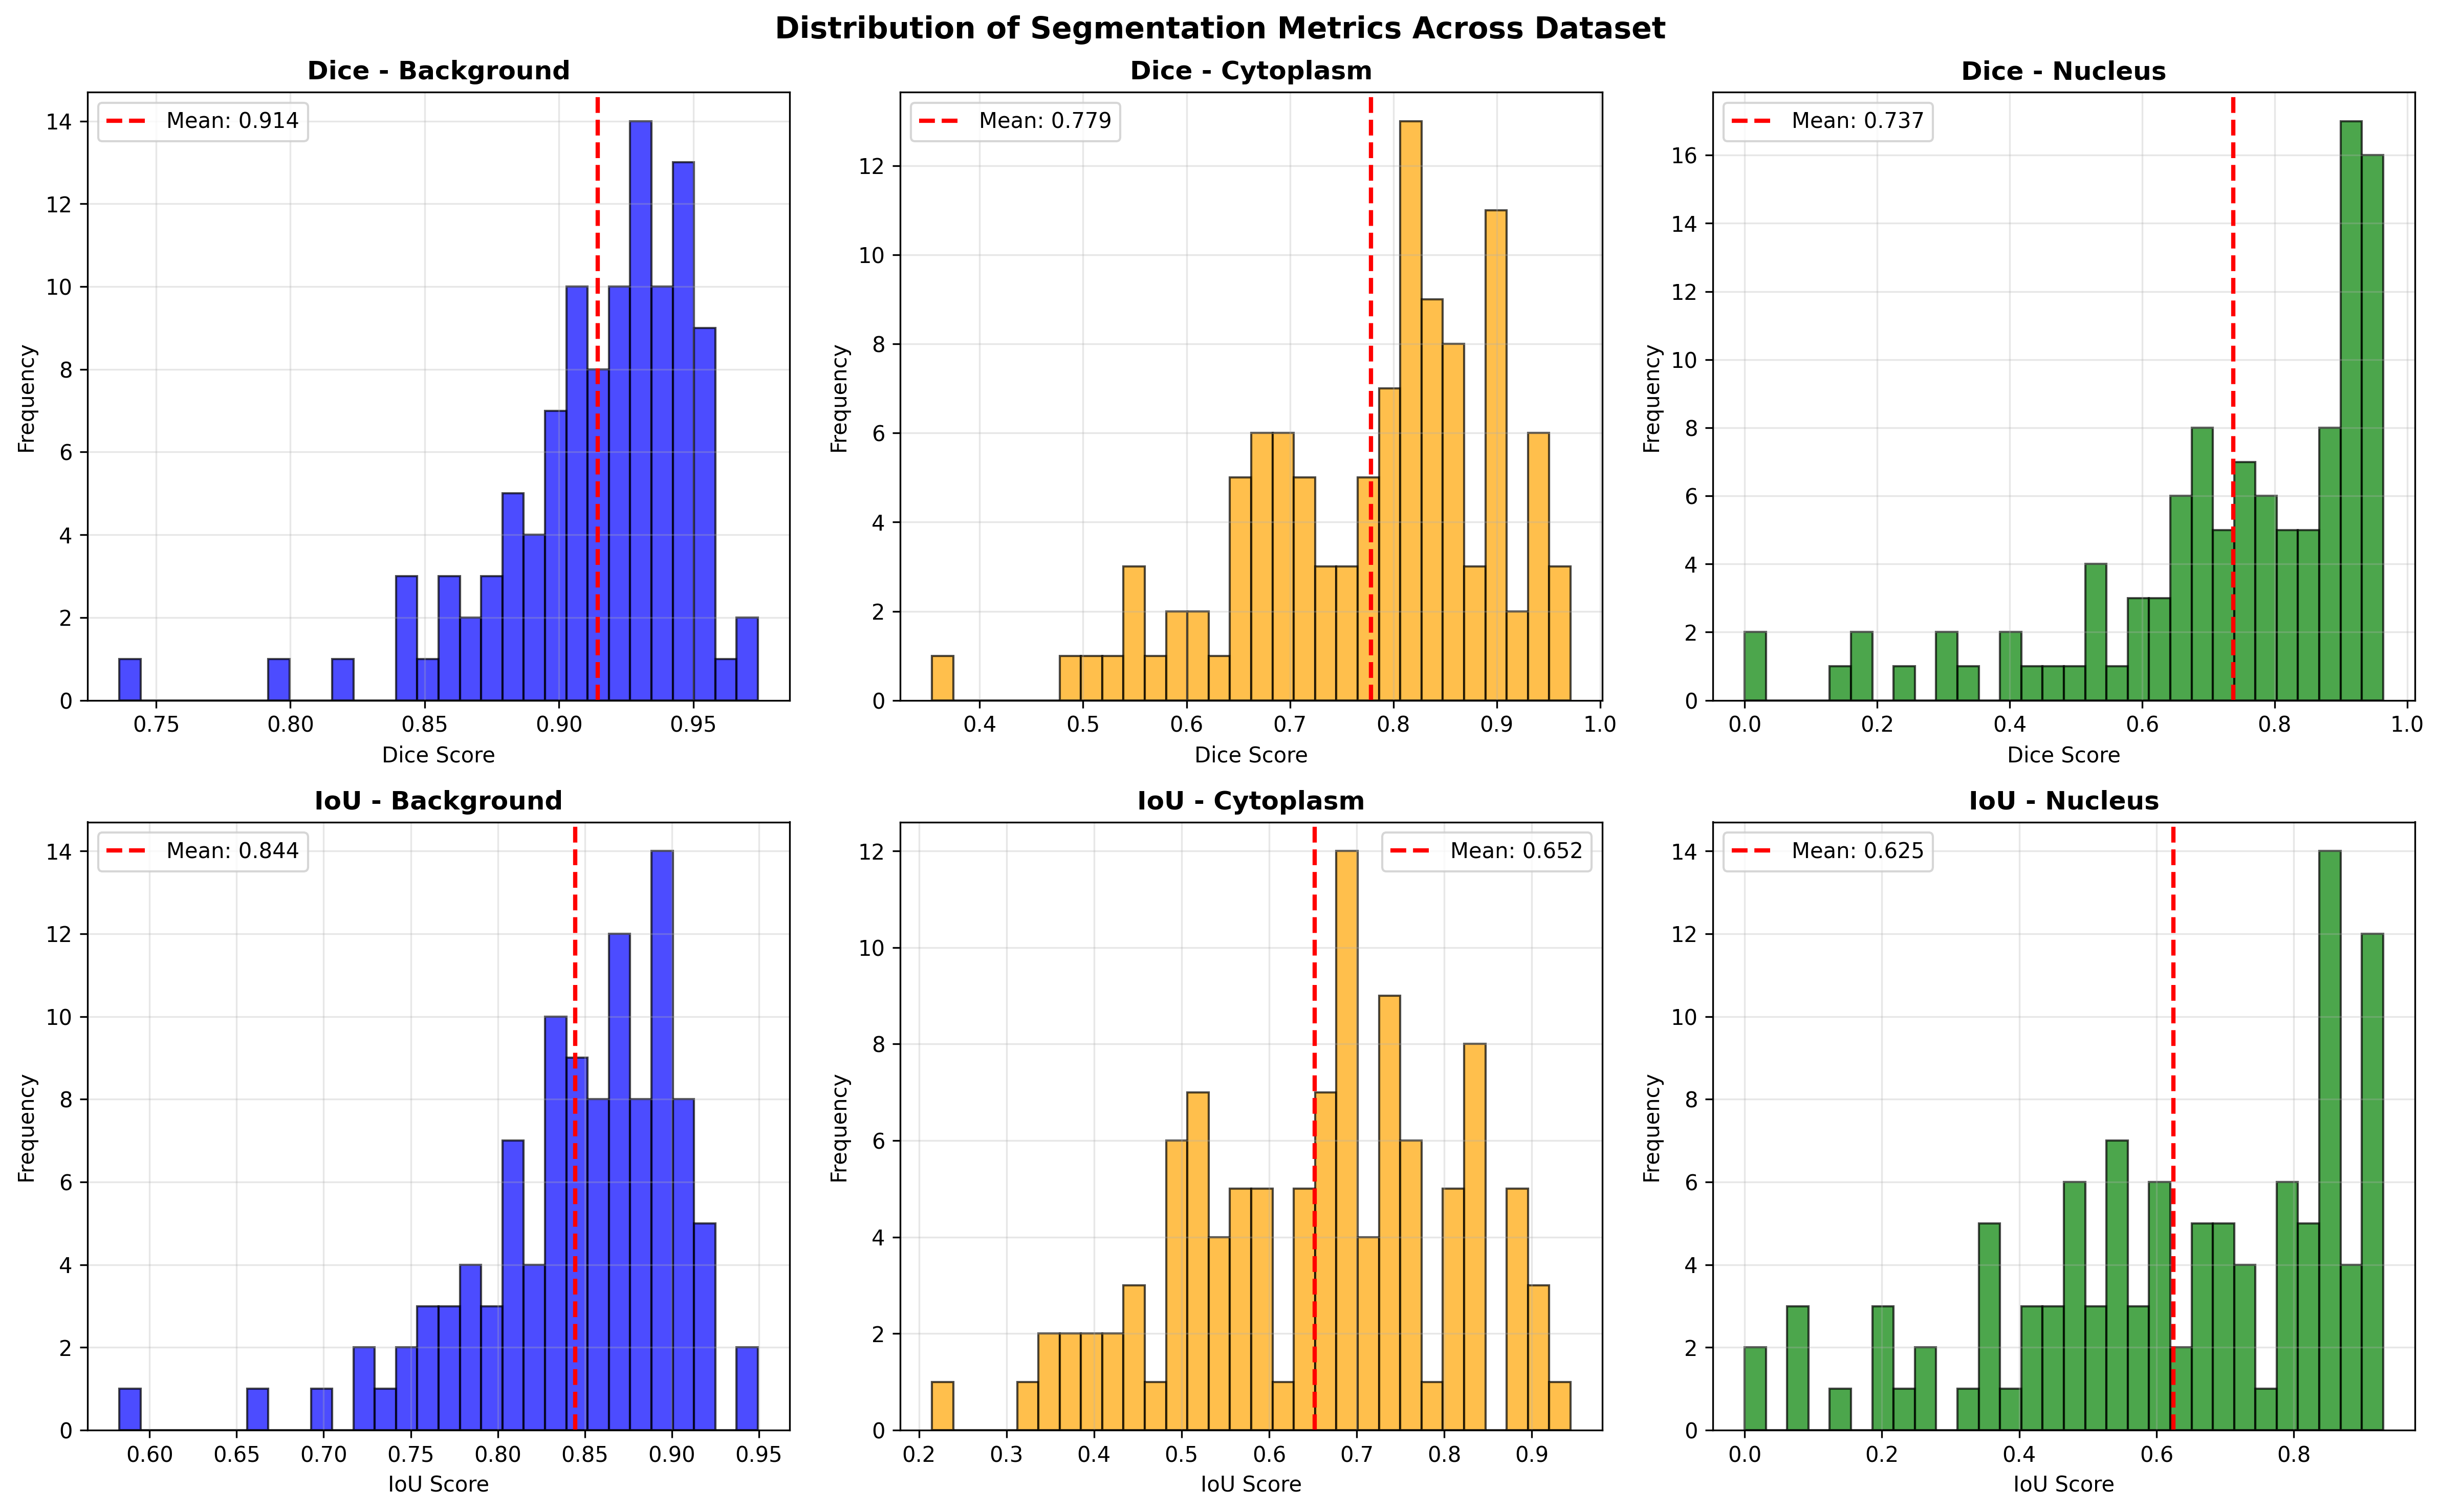

N/C Ratio Statistics:
  True N/C Ratio - Mean: 0.7818, Std: 0.7183
  Pred N/C Ratio - Mean: 1.0772, Std: 0.8293
  Absolute Error - Mean: 0.5148, Std: 0.6199
  Relative Error - Mean: 1.2839, Std: 2.3224


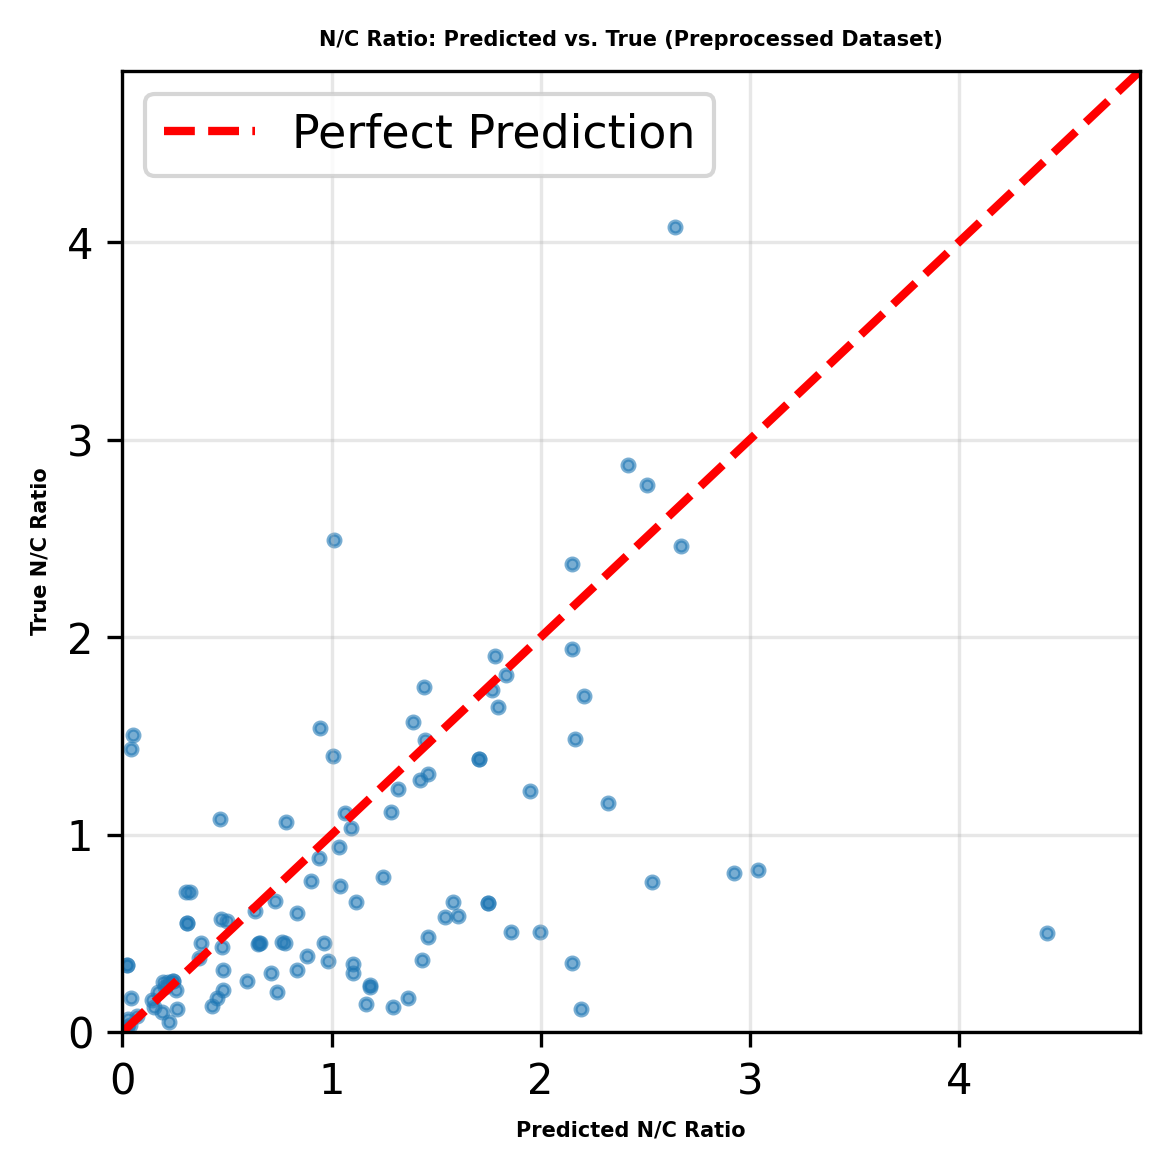

In [14]:
print_aggregate_metrics(aggregate_metrics)
visualize_metric_distributions(all_metrics)

# Define dataset_name for the analyze_nc_ratios function
dataset_name = "Preprocessed Dataset"
analyze_nc_ratios(filtered_labels, segmented_images)

#Bayesian Optimization

##Setup and Data Loading

In [57]:
"""
Chapter 6: Bayesian Optimization of Segmentation Thresholds
Using the actual Chapter 5 preprocessing pipeline
"""

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from scipy.ndimage import gaussian_filter
import cv2
from skimage.restoration import denoise_nl_means
from skimage.filters import unsharp_mask, gaussian
from skimage.morphology import binary_opening, binary_closing, disk
import warnings
warnings.filterwarnings('ignore')

print("✓ All imports successful")

✓ All imports successful


##Data Conversion

In [59]:
# Convert to proper format
X_data = urothelial_cells["X"]
if hasattr(X_data, 'numpy'):
    images_raw = X_data.numpy() * 255
else:
    images_raw = X_data * 255

images = np.transpose(images_raw, (0, 2, 3, 1)).astype(np.uint8)

y_data = urothelial_cells["y"]
if hasattr(y_data, 'numpy'):
    labels = y_data.numpy()
else:
    labels = y_data

print(f"✓ Converted image format:")
print(f"  Images shape: {images.shape}")
print(f"  Labels shape: {labels.shape}")
print(f"  Total images available: {len(images)}")

all_images = images
all_labels = labels

✓ Converted image format:
  Images shape: (200, 256, 256, 3)
  Labels shape: (200, 256, 256)
  Total images available: 200


##Train Test Split

In [60]:
from sklearn.model_selection import train_test_split

print("\n" + "="*70)
print("CREATING TRAIN/VALIDATION/TEST SPLIT (60/20/20)")
print("="*70)

train_idx, temp_idx = train_test_split(
    np.arange(len(all_images)),
    test_size=0.4,
    random_state=42
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    random_state=42
)

train_images = all_images[train_idx]
train_labels = all_labels[train_idx]

val_images = all_images[val_idx]
val_labels = all_labels[val_idx]

test_images = all_images[test_idx]
test_labels = all_labels[test_idx]

print(f"\nTrain set:      {len(train_images)} images ({len(train_images)/len(all_images)*100:.1f}%)")
print(f"Validation set: {len(val_images)} images ({len(val_images)/len(all_images)*100:.1f}%)")
print(f"Test set:       {len(test_images)} images ({len(test_images)/len(all_images)*100:.1f}%)")



CREATING TRAIN/VALIDATION/TEST SPLIT (60/20/20)

Train set:      120 images (60.0%)
Validation set: 40 images (20.0%)
Test set:       40 images (20.0%)


## Display Initial Metrics

# Full Bayesian

In [65]:
"""
Chapter 6: Bayesian Optimization of Segmentation Pipeline Parameters
Assumes: images, labels already loaded and cleaned with filter_images_by_nucleus_count()
"""

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print("✓ All Bayesian Optimization libraries loaded")

# ============================================================================
# FILTER DATA: Keep only images with exactly 1 nucleus
# ============================================================================

print("\n" + "="*70)
print("FILTERING DATA: Removing images with 0, >1 nuclei")
print("="*70)

filtered_images, filtered_labels, valid_indices, report = filter_images_by_nucleus_count(
    images, labels, min_nuclei=1, max_nuclei=1
)

print(f"\nFiltering Report:")
print(f"  Original images: {report['original_count']}")
print(f"  Filtered images: {report['filtered_count']}")
print(f"  Excluded: {report['excluded_count']} ({report['exclusion_rate']:.1f}%)")

print("\n" + "="*70)
print("TRAIN/VALIDATION/TEST SPLIT (60/20/20)")
print("="*70)

# Split cleaned data
train_idx, temp_idx = train_test_split(
    np.arange(len(filtered_images)),
    test_size=0.4,
    random_state=42
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    random_state=42
)

train_images = np.array([filtered_images[i] for i in train_idx])
train_labels = np.array([filtered_labels[i] for i in train_idx])

val_images = np.array([filtered_images[i] for i in val_idx])
val_labels = np.array([filtered_labels[i] for i in val_idx])

test_images = np.array([filtered_images[i] for i in test_idx])
test_labels = np.array([filtered_labels[i] for i in test_idx])

print(f"Total cleaned images: {len(filtered_images)}")
print(f"Train set: {len(train_images)} ({len(train_images)/len(filtered_images)*100:.1f}%)")
print(f"Validation set: {len(val_images)} ({len(val_images)/len(filtered_images)*100:.1f}%)")
print(f"Test set: {len(test_images)} ({len(test_images)/len(filtered_images)*100:.1f}%)")

# ============================================================================
# BAYESIAN OPTIMIZATION CLASS
# ============================================================================

class BayesianPipelineOptimizer:
    """
    Optimize pipeline threshold parameters using Bayesian Optimization.
    """

    def __init__(self, images, labels,
                 nucleus_max_bounds=(0.2, 0.4),
                 cytoplasm_max_bounds=(0.5, 0.8),
                 length_scale=0.1,
                 kappa=2.0):
        """Initialize optimizer.

        Note: cytoplasm_min is automatically set to nucleus_max (no separate optimization).
        This is because pixels below nucleus_max are nucleus, and pixels above are cytoplasm.
        """
        self.images = images
        self.labels = labels
        self.nucleus_max_bounds = nucleus_max_bounds
        self.cytoplasm_max_bounds = cytoplasm_max_bounds
        self.length_scale = length_scale
        self.kappa = kappa

        self.X_obs = []
        self.Y_obs = []

        kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale, (1e-2, 1e2))
        self.gp = GaussianProcessRegressor(
            kernel=kernel,
            alpha=1e-6,
            normalize_y=True,
            n_restarts_optimizer=5,
            random_state=42
        )

    def _normalize_params(self, nucleus_max, cytoplasm_max):
        """Normalize parameters to [0, 1]."""
        n_max = (nucleus_max - self.nucleus_max_bounds[0]) / \
                (self.nucleus_max_bounds[1] - self.nucleus_max_bounds[0])
        c_max = (cytoplasm_max - self.cytoplasm_max_bounds[0]) / \
                (self.cytoplasm_max_bounds[1] - self.cytoplasm_max_bounds[0])
        return np.array([n_max, c_max])

    def _denormalize_params(self, normalized):
        """Denormalize parameters from [0, 1].

        cytoplasm_min is automatically set to nucleus_max.
        """
        n_max = normalized[0] * (self.nucleus_max_bounds[1] - self.nucleus_max_bounds[0]) + \
                self.nucleus_max_bounds[0]
        c_max = normalized[1] * (self.cytoplasm_max_bounds[1] - self.cytoplasm_max_bounds[0]) + \
                self.cytoplasm_max_bounds[0]
        # cytoplasm_min is automatically set to nucleus_max
        c_min = n_max
        return n_max, c_min, c_max

    def _evaluate_loss(self, normalized_params):
        """Evaluate loss at normalized parameter coordinates."""
        nucleus_max, cytoplasm_min, cytoplasm_max = self._denormalize_params(normalized_params)

        # Apply pipeline with these parameters
        params = {
            'nucleus_max': nucleus_max,
            'cytoplasm_min': cytoplasm_min,
            'cytoplasm_max': cytoplasm_max,
            'nl_means_strength': 0.5,
            'unsharp_radius': 2.0,
            'unsharp_amount': 2.0,
            'blur_sigma': 1.5,
            'morph_disk_size': 5,
            'closing_disk_size': 3
        }

        segmented, _, agg_metrics = apply_pipeline_to_dataset(
            self.images, self.labels, params, verbose=False
        )

        # Loss is negative mean Dice (to minimize)
        loss = -agg_metrics['Dice_Mean_mean']
        return loss

    def _ucb_acquisition(self, normalized_params):
        """Compute Upper Confidence Bound acquisition function."""
        if len(self.X_obs) == 0:
            return 0.0

        self.gp.fit(np.array(self.X_obs), np.array(self.Y_obs))

        normalized_params = normalized_params.reshape(1, -1)
        mean, std = self.gp.predict(normalized_params, return_std=True)

        ucb = mean[0] + self.kappa * std[0]
        return ucb

    def add_observation(self, nucleus_max, cytoplasm_max, loss=None):
        """Record an evaluated point.

        cytoplasm_min is automatically set to nucleus_max.
        """
        normalized = self._normalize_params(nucleus_max, cytoplasm_max)
        self.X_obs.append(normalized)

        if loss is None:
            loss = self._evaluate_loss(normalized)

        self.Y_obs.append(loss)
        return loss

    def get_next_candidate(self):
        """Find the point that maximizes the acquisition function."""
        if len(self.X_obs) == 0:
            return self._denormalize_params(np.random.rand(2))

        self.gp.fit(np.array(self.X_obs), np.array(self.Y_obs))

        best_ucb = float('inf')
        best_candidate = None

        for _ in range(10):
            x0 = np.random.rand(2)
            result = minimize(self._ucb_acquisition,
                            x0,
                            bounds=[(0, 1), (0, 1)],
                            method='L-BFGS-B')

            if result.fun < best_ucb:
                best_ucb = result.fun
                best_candidate = result.x

        return self._denormalize_params(best_candidate)

    def optimize(self, n_initial=5, n_iterations=15):
        """Run Bayesian Optimization loop."""

        print("\n" + "="*70)
        print("STEP 2: BAYESIAN OPTIMIZATION OF PIPELINE PARAMETERS")
        print("="*70)

        print(f"\nPhase 1: Random Initialization ({n_initial} evaluations)")
        print("-" * 70)

        for i in range(n_initial):
            nucleus_max = np.random.uniform(*self.nucleus_max_bounds)
            cytoplasm_max = np.random.uniform(*self.cytoplasm_max_bounds)
            loss = self.add_observation(nucleus_max, cytoplasm_max)

            print(f"  Initial {i+1}/{n_initial}: " +
                  f"nuc_max={nucleus_max:.4f}, cyt_max={cytoplasm_max:.4f}, loss={loss:.4f}")

        print(f"\nPhase 2: Bayesian Optimization ({n_iterations} iterations)")
        print("-" * 70)

        for iteration in range(n_iterations):
            nucleus_max, cytoplasm_min, cytoplasm_max = self.get_next_candidate()
            loss = self.add_observation(nucleus_max, cytoplasm_max)

            best_idx = np.argmin(self.Y_obs)
            best_loss = self.Y_obs[best_idx]
            best_nuc, best_cyt_min, best_cyt_max = self._denormalize_params(self.X_obs[best_idx])

            print(f"  Iter {iteration+1}/{n_iterations}: " +
                  f"nuc_max={nucleus_max:.4f}, cyt_max={cytoplasm_max:.4f}, loss={loss:.4f}")
            print(f"    → Best so far: loss={best_loss:.4f}")

        best_idx = np.argmin(self.Y_obs)
        best_nuc, best_cyt_min, best_cyt_max = self._denormalize_params(self.X_obs[best_idx])
        best_loss = self.Y_obs[best_idx]

        print("\n" + "="*70)
        print("OPTIMIZATION COMPLETE")
        print("="*70)
        print(f"\nBest Parameters Found:")
        print(f"  Nucleus Max:      {best_nuc:.6f}")
        print(f"  Cytoplasm Min:    {best_cyt_min:.6f} (= Nucleus Max)")
        print(f"  Cytoplasm Max:    {best_cyt_max:.6f}")
        print(f"  Validation Loss:  {best_loss:.6f}")
        print(f"  Validation Dice:  {-best_loss:.6f}")
        print(f"\nTotal Evaluations: {len(self.Y_obs)}")

        return {
            'best_nucleus_max': best_nuc,
            'best_cytoplasm_min': best_cyt_min,
            'best_cytoplasm_max': best_cyt_max,
            'best_loss': best_loss,
            'best_dice': -best_loss,
            'X_obs': np.array(self.X_obs),
            'Y_obs': np.array(self.Y_obs),
            'optimizer': self
        }

# ============================================================================
# RUN BAYESIAN OPTIMIZATION
# ============================================================================

optimizer = BayesianPipelineOptimizer(
    val_images,
    val_labels,
    nucleus_max_bounds=(0.1, 0.5),
    cytoplasm_max_bounds=(0.5, 1),
    length_scale=0.1,
    kappa=2.0
)

# Use smaller numbers for testing, increase for production
opt_results = optimizer.optimize(n_initial=5, n_iterations=15)

print("\n" + "="*70)
print("NEXT STEPS: Evaluate optimized parameters on TEST set")
print("="*70)
print("\nOptimized parameters:")
print(f"  nucleus_max: {opt_results['best_nucleus_max']:.6f}")
print(f"  cytoplasm_min: {opt_results['best_cytoplasm_min']:.6f} (automatically set to nucleus_max)")
print(f"  cytoplasm_max: {opt_results['best_cytoplasm_max']:.6f}")

✓ All Bayesian Optimization libraries loaded

FILTERING DATA: Removing images with 0, >1 nuclei

Filtering Report:
  Original images: 200
  Filtered images: 108
  Excluded: 92 (46.0%)

TRAIN/VALIDATION/TEST SPLIT (60/20/20)
Total cleaned images: 108
Train set: 64 (59.3%)
Validation set: 22 (20.4%)
Test set: 22 (20.4%)

STEP 2: BAYESIAN OPTIMIZATION OF PIPELINE PARAMETERS

Phase 1: Random Initialization (5 evaluations)
----------------------------------------------------------------------
  Initial 1/5: nuc_max=0.3170, cyt_max=0.6670, loss=-0.6461
  Initial 2/5: nuc_max=0.1852, cyt_max=0.7102, loss=-0.5868
  Initial 3/5: nuc_max=0.1949, cyt_max=0.9222, loss=-0.7146
  Initial 4/5: nuc_max=0.3955, cyt_max=0.9856, loss=-0.7775
  Initial 5/5: nuc_max=0.4499, cyt_max=0.9776, loss=-0.7795

Phase 2: Bayesian Optimization (15 iterations)
----------------------------------------------------------------------
  Iter 1/15: nuc_max=0.4499, cyt_max=0.9776, loss=-0.7795
    → Best so far: loss=-0.779

KeyboardInterrupt: 